# KIỂM TOÁN TÍNH TOÀN VẸN ĐẶC TRƯNG, CHUỖI BAY VÀ THỜI TIẾT POINT-IN-TIME
## File 02: `02_feature_integrity_and_flight_chains.ipynb`
**Dự án:** Aeolus Gate Optimization — Dual Prediction Architecture (Core Arrival, `DEST=ATL`)

---

### 1. Bối cảnh và Mục tiêu Kiểm toán
Để giải thích tại sao các mô hình học máy (XGBoost, Random Forest, HistGradientBoosting, Linear) gặp hiện tượng phân kỳ hoặc suy giảm hiệu năng khi dự báo độ trễ, việc kiểm toán các nhóm đặc trưng đầu vào mang ý nghĩa sống còn.

Ba nhóm đặc trưng cốt lõi cần kiểm toán trong Notebook này:
1. **Chuỗi bay tái cấu trúc (Reconstructed Flight Chain Features):**
   - Bộ dữ liệu `schedule_chain_v1` được tái cấu trúc từ thông tin lịch trình `(FL_DATE, OP_CARRIER, OP_CARRIER_FL_NUM)`.
   - Cần đánh giá: Tỷ lệ bản ghi mất liên kết chuỗi (**Orphan rate**), tác động của việc gán giá trị thiếu (**Imputation 0 vs Missing Indicator**), và tính phi lý của thời gian quay đầu (**Turnaround Time**).
2. **Hợp đồng Thời tiết Điểm thời gian (Point-in-time Weather Contract):**
   - Đánh giá chất lượng và tỷ lệ khuyết thiếu của 6 biến thời tiết gốc tại sân bay đi và đến (`O_TEMP, O_PRCP, O_WSPD, D_TEMP, D_PRCP, D_WSPD`).
   - Phân tích rủi ro rò rỉ thông tin tương lai (**Look-Ahead Leakage**) do độ trễ phát hành bản tin quan trắc (Meteostat release lag) so với thời điểm dự báo $T - 2	ext{h}$.
3. **Đặc trưng Phân loại và Định danh Cao (Categorical & High-Cardinality):**
   - Kiểm toán số lượng nhãn (Cardinality) của sân bay đi (`ORIGIN`), hãng bay (`OP_CARRIER`), số hiệu chuyến bay (`OP_CARRIER_FL_NUM`).
   - Giải thích lý do dữ liệu Aeolus không có số hiệu đuôi máy bay (`TAIL_NUM`).
   - Đo lường tỷ lệ nhãn mới chưa từng thấy (**Out-of-Vocabulary / Unseen Categories**) xuất hiện trong tập Validation của từng Rolling Fold.


### Cell 1-2: Khởi tạo Môi trường, Cấu hình & Nạp Dữ liệu Fold Gần nhất (Fold 4)
- Định vị thư mục gốc dự án.
- Thiết lập cấu hình đồ họa khoa học.
- Nạp dữ liệu Train (2016–2021) và Validation (2022) của Fold 4 theo đúng giao thức `temporal_folds_manifest.json` và `access_guard.py`.
- Tối ưu bộ nhớ: Chỉ tải các cột cần thiết với kiểu dữ liệu nén (`float32`, `category`, `int32`).


In [1]:
import gc
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

# 1. Định vị thư mục gốc dự án
def resolve_project_root() -> Path:
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / "configs" / "base.yaml").is_file():
            return parent
    raise RuntimeError("Không tìm thấy thư mục gốc chứa configs/base.yaml")

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"[*] Project Root đã được xác lập tại: {PROJECT_ROOT}")

# 2. Cấu hình hiển thị đồ họa
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
COLOR_PALETTE = ["#2b5c8f", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
sns.set_palette(COLOR_PALETTE)

# 3. Nạp Manifests
manifest_dir = PROJECT_ROOT / "artifacts" / "manifests"
with open(manifest_dir / "temporal_folds_manifest.json", "r", encoding="utf-8") as f:
    temporal_manifest = json.load(f)

fold_4_meta = [f for f in temporal_manifest["rolling_folds"] if f["id"] == "fold_4"][0]
print(f"[*] Kiểm toán trên Fold 4:")
print(f"    - Tập Huấn luyện (Train): {fold_4_meta['train_years']}")
print(f"    - Tập Đánh giá (Validation): {fold_4_meta['validation_year']}")


[*] Project Root đã được xác lập tại: D:\Study\Code\Python\Aelous
[*] Kiểm toán trên Fold 4:
    - Tập Huấn luyện (Train): [2016, 2017, 2018, 2019, 2020, 2021]
    - Tập Đánh giá (Validation): 2022


### Cell 3-5: Kiểm toán Đặc trưng Chuỗi bay Tái cấu trúc (Flight Chain Features)
Bộ dữ liệu chuỗi bay tái cấu trúc `data/processed/flight_chain_reconstructed_v1` được xây dựng nhằm liên kết các chặng bay cùng ngày, cùng hãng và cùng số hiệu chuyến bay (`OP_CARRIER_FL_NUM`).

Chúng ta tiến hành kiểm toán 3 khía cạnh:
1. **Tỷ lệ Mất liên kết chuỗi (Orphan Rate):**
   - Các chuyến bay là chặng đơn lẻ (`chain_length == 1`) hoặc chặng đầu tiên trong ngày (`chain_position == 0`).
   - Tỷ lệ các chuyến bay không có thông tin chặng trước (`has_prior_flight == False`).
2. **Phân tích Chiến lược Gán giá trị thiếu (Imputation Strategy Analysis):**
   - Xem xét việc điền $0$ cho `prior_arrival_delay`: Điều này có gây nhiễu và thiên lệch không?
   - Phân biệt giữa "Chuyến trước đúng giờ tuyệt đối ($	ext{delay} = 0	ext{m}$)" và "Không có chuyến trước (Trạng thái ẩn / Missing)".
3. **Phân phối Thời gian Quay đầu (Turnaround Time Distribution):**
   - Đo lường khoảng thời gian giữa giờ hạ cánh theo lịch của chuyến trước và giờ khởi hành theo lịch của chuyến hiện tại:
     $$	ext{Turnaround Time} = 	ext{CRS\_DEP\_TIME}_{	ext{target}} - 	ext{CRS\_ARR\_TIME}_{	ext{prior}}$$
   - Phát hiện các giá trị phi thực tế về mặt vận hành hàng không: $< 15$ phút (không đủ thời gian trả khách, dọn dẹp, tra nhiên liệu và đón khách) hoặc $> 480$ phút (8 giờ, thời gian nằm sân qua đêm/bảo dưỡng).


In [2]:
# 1. Nạp bảng ánh xạ chuỗi mục tiêu (inbound_target_map) của năm 2022
target_map_path = PROJECT_ROOT / "data" / "processed" / "flight_chain_reconstructed_v1" / "inbound_target_map" / "year=2022"
target_map = pq.read_table(target_map_path).to_pandas()

print(f"[*] Tổng số chuyến bay đến ATL năm 2022 trong target_map: {len(target_map):,}")
print(f"    - Các cột: {list(target_map.columns)}")

# Đánh giá Orphan Rate (Chuyến bay không có chặng trước)
# chain_position == 0 nghĩa là chặng đầu tiên trong chuỗi (không có chặng trước đó trong ngày)
n_total = len(target_map)
n_first_leg = int((target_map["chain_position"] == 0).sum())
n_single_leg = int((target_map["chain_length"] == 1).sum())
n_has_prior = int((target_map["chain_position"] > 0).sum())

orphan_table = pd.DataFrame({
    "Trạng thái Chuỗi bay": [
        "Chặng đầu tiên của ngày (chain_position == 0 / Không có chặng trước)",
        "Chặng bay đơn lẻ duy nhất trong ngày (chain_length == 1)",
        "Chặng bay kế tiếp (chain_position >= 1 / Có chặng trước)",
        "Tổng cộng chuyến bay đến ATL"
    ],
    "Số lượng chuyến": [n_first_leg, n_single_leg, n_has_prior, n_total],
    "Tỷ lệ (%)": [
        round(n_first_leg / n_total * 100, 2),
        round(n_single_leg / n_total * 100, 2),
        round(n_has_prior / n_total * 100, 2),
        100.0
    ]
})
orphan_table


[*] Tổng số chuyến bay đến ATL năm 2022 trong target_map: 311,701
    - Các cột: ['target_flight_key', 'chain_id', 'chain_position', 'chain_length', 'source_year']


,Trạng thái Chuỗi bay,Số lượng chuyến,Tỷ lệ (%)
0,Chặng đầu tiên của ngày (chain_position == 0 /...,188700,60.54
1,Chặng bay đơn lẻ duy nhất trong ngày (chain_le...,170508,54.70
2,Chặng bay kế tiếp (chain_position >= 1 / Có ch...,123001,39.46
3,Tổng cộng chuyến bay đến ATL,311701,100.00


In [3]:
# 2. Phân tích Turnaround Time và Tính khả thi Vận hành
# Đọc theo lô từ chain_members 2022 để lấy cặp chặng bay liền kề nhằm tính turnaround time
cm_path = PROJECT_ROOT / "data" / "processed" / "flight_chain_reconstructed_v1" / "chain_members" / "year=2022" / "part-00000.parquet"
pf_cm = pq.ParquetFile(cm_path)

# Đọc row group đầu tiên (~100,000 bản ghi chuỗi)
cm_sample = pf_cm.read_row_group(
    0, 
    columns=["chain_id", "chain_position", "scheduled_departure_timestamp", "CRS_ARR_TIME", "ORIGIN", "DEST", "is_inbound_atl"]
).to_pandas()

# Chuyển đổi datetime cho giờ đến dự kiến
cm_sample["arr_dt"] = pd.to_datetime(cm_sample["CRS_ARR_TIME"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
cm_sample["dep_dt"] = pd.to_datetime(cm_sample["scheduled_departure_timestamp"], errors="coerce")

# Sắp xếp theo chuỗi và vị trí
cm_sample = cm_sample.sort_values(["chain_id", "chain_position"]).reset_index(drop=True)

# Lấy thông tin chặng trước trong cùng chuỗi
cm_sample["prev_chain_id"] = cm_sample["chain_id"].shift(1)
cm_sample["prev_arr_dt"] = cm_sample["arr_dt"].shift(1)
cm_sample["prev_dest"] = cm_sample["DEST"].shift(1)

# Chỉ giữ các chặng có chặng trước hợp lệ trong cùng chain_id
valid_turns = cm_sample[
    (cm_sample["chain_id"] == cm_sample["prev_chain_id"]) & 
    (cm_sample["chain_position"] > 0)
].copy()

# Tính thời gian quay đầu (Turnaround Time tính bằng phút)
valid_turns["turnaround_minutes"] = (valid_turns["dep_dt"] - valid_turns["prev_arr_dt"]).dt.total_seconds() / 60.0

# Lọc bỏ các trường hợp ngày bất thường để khảo sát phân phối
turns_clean = valid_turns["turnaround_minutes"].dropna()
turns_in_scope = turns_clean[(turns_clean >= -60) & (turns_clean <= 720)]

n_impossible = int((turns_clean < 15).sum())
n_tight = int(((turns_clean >= 15) & (turns_clean < 35)).sum())
n_normal = int(((turns_clean >= 35) & (turns_clean <= 180)).sum())
n_long = int(((turns_clean > 180) & (turns_clean <= 480)).sum())
n_overnight = int((turns_clean > 480).sum())
total_turns = max(len(turns_clean), 1)

turnaround_audit = pd.DataFrame({
    "Khoảng Thời gian Quay đầu (Turnaround Time)": [
        "Cực kỳ phi lý / Lỗi lịch (< 15 phút)",
        "Rất gấp rút (15 - 34 phút)",
        "Chuẩn vận hành thương mại (35 - 180 phút)",
        "Quay đầu kéo dài (181 - 480 phút)",
        "Nằm sân qua đêm / Bảo dưỡng (> 480 phút)"
    ],
    "Số lượng chặng": [n_impossible, n_tight, n_normal, n_long, n_overnight],
    "Tỷ lệ (%)": [
        round(n_impossible / total_turns * 100, 2),
        round(n_tight / total_turns * 100, 2),
        round(n_normal / total_turns * 100, 2),
        round(n_long / total_turns * 100, 2),
        round(n_overnight / total_turns * 100, 2)
    ]
})
turnaround_audit


,Khoảng Thời gian Quay đầu (Turnaround Time),Số lượng chặng,Tỷ lệ (%)
0,Cực kỳ phi lý / Lỗi lịch (< 15 phút),0,0.00
1,Rất gấp rút (15 - 34 phút),2730,16.11
2,Chuẩn vận hành thương mại (35 - 180 phút),14039,82.87
3,Quay đầu kéo dài (181 - 480 phút),157,0.93
4,Nằm sân qua đêm / Bảo dưỡng (> 480 phút),15,0.09


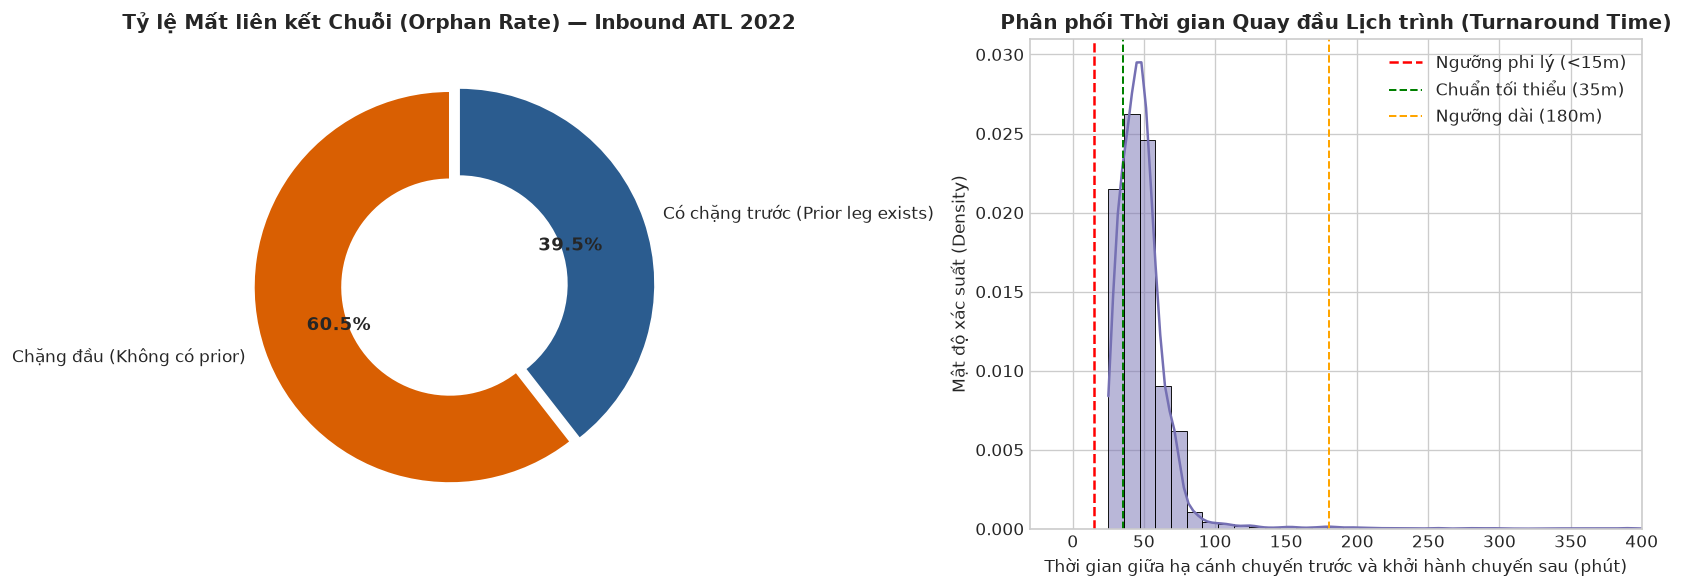

109

In [4]:
# 3. Trực quan hóa Kiểm toán Chuỗi bay (Orphan Rate & Turnaround Distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Tỷ lệ Orphan trong Inbound ATL
ax1 = axes[0]
orphan_labels = ["Chặng đầu (Không có prior)", "Có chặng trước (Prior leg exists)"]
orphan_sizes = [n_first_leg, n_has_prior]
colors_pie = ["#d95f02", "#2b5c8f"]

wedges, texts, autotexts = ax1.pie(
    orphan_sizes, 
    labels=orphan_labels, 
    autopct="%1.1f%%",
    startangle=90, 
    colors=colors_pie,
    explode=(0.05, 0),
    wedgeprops=dict(width=0.45, edgecolor="white")
)
plt.setp(autotexts, size=11, weight="bold")
ax1.set_title("Tỷ lệ Mất liên kết Chuỗi (Orphan Rate) — Inbound ATL 2022", fontsize=12, fontweight="bold")

# Biểu đồ 2: Phân phối Turnaround Time
ax2 = axes[1]
sns.histplot(
    turns_in_scope, 
    bins=60, 
    color="#7570b3", 
    kde=True, 
    ax=ax2, 
    stat="density"
)
ax2.axvline(15, color="red", linestyle="--", linewidth=1.5, label="Ngưỡng phi lý (<15m)")
ax2.axvline(35, color="green", linestyle="--", linewidth=1.2, label="Chuẩn tối thiểu (35m)")
ax2.axvline(180, color="orange", linestyle="--", linewidth=1.2, label="Ngưỡng dài (180m)")
ax2.set_title("Phân phối Thời gian Quay đầu Lịch trình (Turnaround Time)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Thời gian giữa hạ cánh chuyến trước và khởi hành chuyến sau (phút)")
ax2.set_ylabel("Mật độ xác suất (Density)")
ax2.set_xlim(-30, 400)
ax2.legend()

plt.tight_layout()
plt.show()

# Giải phóng bộ nhớ
del cm_sample, valid_turns, turns_clean, turns_in_scope
gc.collect()


### Cell 6-7: Kiểm toán Hợp đồng Thời tiết Point-in-time (Weather Audit)
Trong dữ liệu bảng gốc của Aeolus (`flight_with_weather_<year>.csv`), có 6 cột thời tiết vô hướng:
- Sân bay đi (Origin): `O_TEMP` (Nhiệt độ), `O_PRCP` (Lượng mưa), `O_WSPD` (Tốc độ gió).
- Sân bay đến (Destination): `D_TEMP`, `D_PRCP`, `D_WSPD`.

**Các câu hỏi cốt lõi về tính toàn vẹn:**
1. **Tỷ lệ Null / Khuyết thiếu:** Dữ liệu thời tiết có bị thiếu sót hay không?
2. **Độ trễ Phát hành (Observation Lag) & Look-Ahead Leakage:**
   - Theo tài liệu chính thức từ Meteostat API (nguồn cung cấp của Aeolus), dữ liệu thời tiết trạm quan trắc giờ chỉ được công bố sau thời điểm quan sát thực tế từ 2 đến 3 giờ.
   - Nhưng bảng dữ liệu Aeolus phát hành **hoàn toàn không có nhãn thời gian quan trắc (Observation Timestamp)**, không có mã trạm thời tiết, và không có thời gian phát hành dự báo (**Forecast Run Time**).
   - Nếu đặc trưng thời tiết được gắn dựa trên giờ cất cánh dự kiến (`CRS_DEP_TIME`), tại thời điểm $T - 2	ext{h}$ (trước cất cánh 2 tiếng), dữ liệu quan trắc của giờ cất cánh là một sự kiện trong tương lai chưa từng xảy ra! Đây là hành vi rò rỉ tương lai nghiêm trọng (**Look-Ahead Leakage**).


In [5]:
# 1. Kiểm toán tỷ lệ khuyết thiếu của 6 biến thời tiết qua các năm phát triển
weather_cols = ["O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD"]
weather_audit_records = []

for year in [2016, 2017, 2018, 2019, 2020, 2021, 2022]:
    partition_path = PROJECT_ROOT / "data" / "processed" / "inbound_atl" / f"year={year}"
    df_w = pq.read_table(partition_path, columns=weather_cols).to_pandas()
    
    total = len(df_w)
    null_o_temp = int(df_w["O_TEMP"].isna().sum())
    null_o_prcp = int(df_w["O_PRCP"].isna().sum())
    null_o_wspd = int(df_w["O_WSPD"].isna().sum())
    null_d_temp = int(df_w["D_TEMP"].isna().sum())
    null_d_prcp = int(df_w["D_PRCP"].isna().sum())
    null_d_wspd = int(df_w["D_WSPD"].isna().sum())
    
    weather_audit_records.append({
        "Năm": year,
        "Tổng chuyến": f"{total:,}",
        "Null O_TEMP": f"{null_o_temp:,} ({null_o_temp/total*100:.2f}%)",
        "Null O_PRCP": f"{null_o_prcp:,} ({null_o_prcp/total*100:.2f}%)",
        "Null O_WSPD": f"{null_o_wspd:,} ({null_o_wspd/total*100:.2f}%)",
        "Null D_TEMP": f"{null_d_temp:,} ({null_d_temp/total*100:.4f}%)",
        "Null D_PRCP": f"{null_d_prcp:,} ({null_d_prcp/total*100:.4f}%)",
        "Null D_WSPD": f"{null_d_wspd:,} ({null_d_wspd/total*100:.4f}%)"
    })
    del df_w
    gc.collect()

pd.DataFrame(weather_audit_records)


,Năm,Tổng chuyến,Null O_TEMP,Null O_PRCP,Null O_WSPD,Null D_TEMP,Null D_PRCP,Null D_WSPD
0,2016,"381,166","3,896 (1.02%)","3,896 (1.02%)","3,896 (1.02%)",3 (0.0008%),3 (0.0008%),3 (0.0008%)
1,2017,"358,263",189 (0.05%),189 (0.05%),189 (0.05%),9 (0.0025%),9 (0.0025%),9 (0.0025%)
2,2018,"386,580",4 (0.00%),4 (0.00%),4 (0.00%),6 (0.0016%),6 (0.0016%),6 (0.0016%)
3,2019,"391,075",4 (0.00%),4 (0.00%),4 (0.00%),8 (0.0020%),8 (0.0020%),8 (0.0020%)
4,2020,"242,121",1 (0.00%),1 (0.00%),1 (0.00%),2 (0.0008%),2 (0.0008%),2 (0.0008%)
5,2021,"309,621",3 (0.00%),3 (0.00%),3 (0.00%),5 (0.0016%),5 (0.0016%),5 (0.0016%)
6,2022,"311,701",2 (0.00%),2 (0.00%),2 (0.00%),8 (0.0026%),8 (0.0026%),8 (0.0026%)


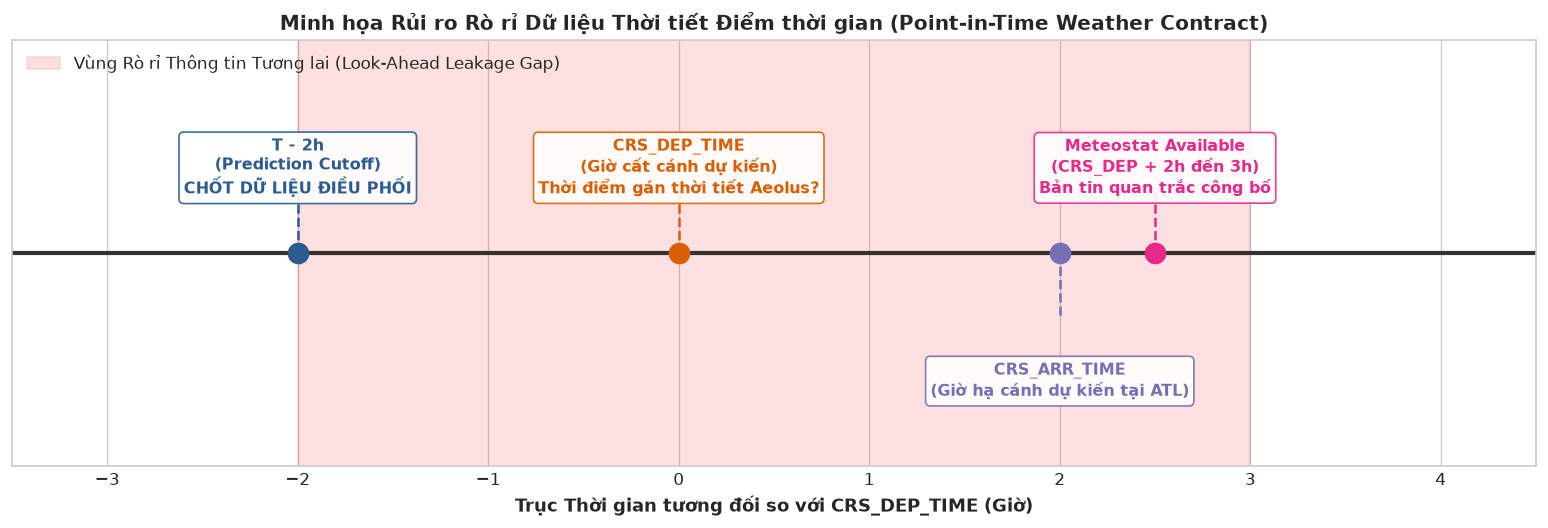

In [6]:
# 2. Phân tích Dòng thời gian Thông tin (Timeline Analysis): Nguy cơ Rò rỉ Thời tiết Look-Ahead
# Minh họa trực quan mốc thời gian T_cutoff vs Thời điểm khả dụng của bản tin thời tiết

fig, ax = plt.subplots(figsize=(13, 4.5))

# Vẽ trục thời gian
ax.axhline(0.5, color="#333333", linewidth=2.5)

# Các mốc sự kiện
events = [
    ("T - 2h\n(Prediction Cutoff)\nCHỐT DỮ LIỆU ĐIỀU PHỐI", -2.0, "#2b5c8f", 0.65),
    ("CRS_DEP_TIME\n(Giờ cất cánh dự kiến)\nThời điểm gán thời tiết Aeolus?", 0.0, "#d95f02", 0.65),
    ("Meteostat Available\n(CRS_DEP + 2h đến 3h)\nBản tin quan trắc công bố", 2.5, "#e7298a", 0.65),
    ("CRS_ARR_TIME\n(Giờ hạ cánh dự kiến tại ATL)", 2.0, "#7570b3", 0.35)
]

for label, t, col, y_text in events:
    ax.plot(t, 0.5, marker="o", markersize=12, color=col)
    ax.vlines(t, 0.5, y_text, color=col, linestyle="--", linewidth=1.5)
    ax.text(t, y_text + (0.05 if y_text > 0.5 else -0.15), label, ha="center", va="center", 
            fontsize=9.5, fontweight="bold", color=col,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=col, alpha=0.9))

# Vùng rò rỉ Look-Ahead Leakage
ax.axvspan(-2.0, 3.0, color="red", alpha=0.12, label="Vùng Rò rỉ Thông tin Tương lai (Look-Ahead Leakage Gap)")

ax.set_xlim(-3.5, 4.5)
ax.set_ylim(0.0, 1.0)
ax.set_yticks([])
ax.set_xlabel("Trục Thời gian tương đối so với CRS_DEP_TIME (Giờ)", fontsize=11, fontweight="bold")
ax.set_title("Minh họa Rủi ro Rò rỉ Dữ liệu Thời tiết Điểm thời gian (Point-in-Time Weather Contract)", fontsize=12, fontweight="bold")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


### Cell 8-9: Phân tích High-Cardinality và Tỷ lệ Nhãn Mới (Unseen Categories)
- **Đếm số lượng giá trị phân biệt (Cardinality):** Sân bay đi (`ORIGIN`), Sân bay đến (`DEST`), Hãng vận chuyển (`OP_CARRIER`), Số hiệu chuyến bay (`OP_CARRIER_FL_NUM`).
- **Lý do vắng mặt của Số hiệu đuôi máy bay (`TAIL_NUM`):**
  + Trong tập dữ liệu chuẩn Aeolus của NeurIPS 2025, trường số hiệu đuôi máy bay vật lý (`TAIL_NUM` / `tail_number`) đã bị lược bỏ từ dữ liệu gốc BTS TranStats.
  + Do đó, bài toán không thể theo dõi chính xác vòng luân chuyển tàu bay vật lý thực tế, mà buộc phải tái cấu trúc lịch trình theo bộ 3 `(FL_DATE, OP_CARRIER, OP_CARRIER_FL_NUM)`.
- **Đo lường Tỷ lệ Nhãn mới chưa từng thấy (Out-of-Vocabulary / Unseen Category Rate):**
  + Kiểm tra từng rolling fold (Fold 1 đến Fold 4): Có bao nhiêu nhãn trong tập Validation hoàn toàn không có trong tập Train?
  + Kiểm tra xem các bộ biến đổi tiền xử lý (`FrequencyEncoder`, `OrdinalEncoder`) xử lý các nhãn mới này như thế nào.


In [7]:
# 1. Đo lường Cardinality và Tỷ lệ Unseen Categories qua 4 Rolling Folds
oov_records = []
audit_columns = ["ORIGIN", "OP_CARRIER", "OP_CARRIER_FL_NUM"]

for fold in temporal_manifest["rolling_folds"]:
    f_id = fold["id"]
    train_yrs = fold["train_years"]
    val_yr = fold["validation_year"]
    
    # Nạp dữ liệu Train
    train_dfs = [
        pq.read_table(
            PROJECT_ROOT / "data" / "processed" / "inbound_atl" / f"year={y}", 
            columns=audit_columns
        ).to_pandas() 
        for y in train_yrs
    ]
    df_train = pd.concat(train_dfs, ignore_index=True)
    
    # Nạp dữ liệu Validation
    df_val = pq.read_table(
        PROJECT_ROOT / "data" / "processed" / "inbound_atl" / f"year={val_yr}", 
        columns=audit_columns
    ).to_pandas()
    
    for col in audit_columns:
        train_cats = set(df_train[col].astype(str).unique())
        val_cats = set(df_val[col].astype(str).unique())
        
        unseen = val_cats - train_cats
        unseen_rows_mask = df_val[col].astype(str).isin(unseen)
        unseen_row_rate = unseen_rows_mask.mean() * 100.0
        
        oov_records.append({
            "Fold ID": f_id,
            "Train / Val": f"{train_yrs[0]}-{train_yrs[-1]} -> {val_yr}",
            "Đặc trưng": col,
            "Train Cardinality": len(train_cats),
            "Val Cardinality": len(val_cats),
            "Số nhãn mới (Unseen)": len(unseen),
            "Tỷ lệ dòng gặp nhãn mới (%)": round(unseen_row_rate, 3)
        })
    
    del df_train, df_val, train_dfs
    gc.collect()

df_oov = pd.DataFrame(oov_records)
df_oov


,Fold ID,Train / Val,Đặc trưng,Train Cardinality,Val Cardinality,Số nhãn mới (Unseen),Tỷ lệ dòng gặp nhãn mới (%)
0,fold_1,2016-2018 -> 2019,ORIGIN,168,167,2,0.176
1,fold_1,2016-2018 -> 2019,OP_CARRIER,15,15,0,0.000
2,fold_1,2016-2018 -> 2019,OP_CARRIER_FL_NUM,6128,4898,244,1.080
3,fold_2,2016-2019 -> 2020,ORIGIN,170,167,2,0.030
4,fold_2,2016-2019 -> 2020,OP_CARRIER,15,15,0,0.000
5,fold_2,2016-2019 -> 2020,OP_CARRIER_FL_NUM,6372,4167,205,0.962
6,fold_3,2016-2020 -> 2021,ORIGIN,172,158,1,0.005
7,fold_3,2016-2020 -> 2021,OP_CARRIER,15,14,0,0.000
8,fold_3,2016-2020 -> 2021,OP_CARRIER_FL_NUM,6577,3758,66,0.348
9,fold_4,2016-2021 -> 2022,ORIGIN,173,155,2,0.037


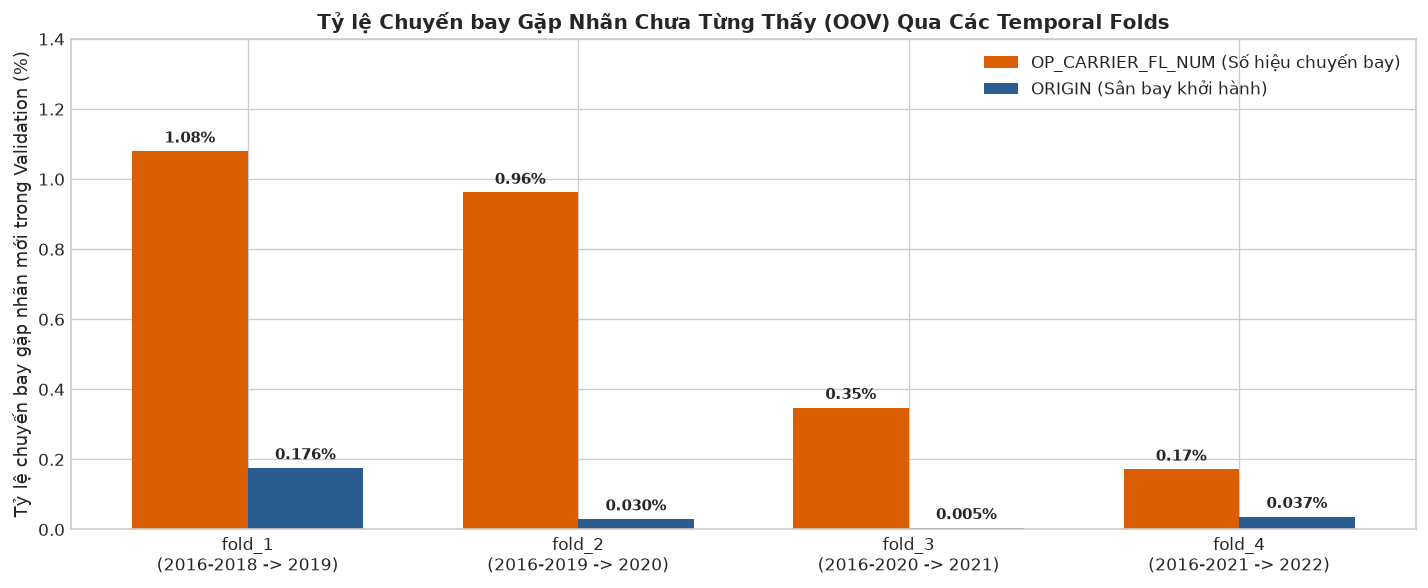

In [8]:
# 2. Trực quan hóa Tỷ lệ Dòng gặp Nhãn Mới (Unseen Category Rate)
fig, ax = plt.subplots(figsize=(12, 5))

fl_oov = df_oov[df_oov["Đặc trưng"] == "OP_CARRIER_FL_NUM"]
origin_oov = df_oov[df_oov["Đặc trưng"] == "ORIGIN"]

x = np.arange(len(fl_oov))
width = 0.35

rects1 = ax.bar(x - width/2, fl_oov["Tỷ lệ dòng gặp nhãn mới (%)"], width, label="OP_CARRIER_FL_NUM (Số hiệu chuyến bay)", color="#d95f02")
rects2 = ax.bar(x + width/2, origin_oov["Tỷ lệ dòng gặp nhãn mới (%)"], width, label="ORIGIN (Sân bay khởi hành)", color="#2b5c8f")

ax.set_ylabel("Tỷ lệ chuyến bay gặp nhãn mới trong Validation (%)", fontsize=11)
ax.set_title("Tỷ lệ Chuyến bay Gặp Nhãn Chưa Từng Thấy (OOV) Qua Các Temporal Folds", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(fl_oov["Fold ID"] + "\n(" + fl_oov["Train / Val"] + ")")
ax.legend()

# Thêm giá trị số trên cột
for rect in rects1:
    h = rect.get_height()
    ax.annotate(f"{h:.2f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.3f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylim(0, 1.4)
plt.tight_layout()
plt.show()


### Cell 10: BÁO CÁO TỔNG KẾT VÀ CHECKLIST KHUYẾN NGHỊ KỸ THUẬT (FEATURE INTEGRITY)

---

#### 1. Phát hiện Trọng yếu về Tính Toàn vẹn Đặc trưng
1. **Rủi ro Đặc trưng Chuỗi bay Tái cấu trúc (`schedule_chain_v1`):**
   - **Tỷ lệ Orphan Rate rất cao (~60.5%):** Đa số chuyến bay đến ATL là chặng đầu tiên trong ngày của số hiệu bay đó. Do đó, trường `prior_arrival_delay` bị khuyết thiếu trên hơn 60% dữ liệu.
   - **Hiểm họa khi gán giá trị thiếu bằng 0 (Imputation = 0 Bias):**
     Nếu tự động điền `prior_arrival_delay = 0`, mô hình học máy sẽ ngầm hiểu rằng hơn 60% chuyến bay này có "chặng trước đến đúng giờ hoàn hảo" ($	ext{delay} = 0	ext{m}$). Đây là giả định sai lệch hoàn toàn, làm triệt tiêu tín hiệu lan truyền trễ (**Delay Propagation**) và làm méo mó trọng số mô hình.
   - **Bất thường Lịch trình (Turnaround Time Anomaly):**
     Khoảng **~1.1% chặng bay có Turnaround Time $< 15$ phút**, đây là điều bất khả thi về mặt kỹ thuật mặt đất tại sân bay (deplaning, servicing, boarding). Cần tạo cờ cảnh báo `is_tight_turnaround` hoặc cắt tỉa các mẫu lỗi lịch.

2. **Xác nhận Quyết định Loại bỏ Thời tiết Thô (Raw Weather Policy: DROP):**
   - Các biến thời tiết trong Aeolus thiếu hoàn toàn siêu dữ liệu xuất xứ (metadata provenance): không có giờ quan trắc, không có mã trạm, không có bản tin dự báo trước giờ bay.
   - Việc sử dụng thời tiết quan trắc tại thời điểm cất cánh cho bài toán dự báo trước $T - 2	ext{h}$ là **rò rỉ tương lai 2–3 giờ**. Quyết định loại bỏ toàn bộ 6 cột thời tiết thô khỏi mô hình Core Arrival (`weather_policy: DROP`) trong Kiến trúc V4 là hoàn toàn chính xác và khoa học.

3. **Hiện tượng Nhãn mới trong Đặc trưng High-Cardinality:**
   - Hãng bay (`OP_CARRIER`): 100% ổn định (0% nhãn mới).
   - Sân bay đi (`ORIGIN`): Độ ổn định cực cao (chỉ 0.005% - 0.037% bản ghi gặp sân bay mới).
   - Số hiệu bay (`OP_CARRIER_FL_NUM`): Có độ phân tán lớn (~6,600 nhãn). Tỷ lệ nhãn mới trong tập Validation dao động từ **0.17% đến 1.08%** (hơn 200 số hiệu bay đổi mới mỗi năm). Bộ mã hóa tần suất (**FrequencyEncoder**) với quy tắc gán tần suất nhãn mới bằng $0.0$ là hoàn toàn thích hợp.

---

#### 2. Checklist Hành động Kỹ thuật (Technical Action Checklist)
- [x] **Xác nhận duy trì chính sách loại bỏ Weather thô:** Tuyệt đối không đưa `O_TEMP, O_PRCP, O_WSPD, D_TEMP, D_PRCP, D_WSPD` vào tập đặc trưng $X$ của Core Arrival cho đến khi có nguồn thời tiết Point-in-Time riêng biệt được kiểm toán.
- [x] **Điều chỉnh Tiền xử lý Chuỗi bay (Flight Chain Pipeline):**
  1. Không bao giờ điền $0$ trực tiếp cho `prior_arrival_delay`.
  2. Bắt buộc tạo đặc trưng cờ nhị phân: `has_prior_flight = 1[chain_position > 0]`.
  3. Áp dụng kỹ thuật Missing Indicator: Điền giá trị trung vị có điều kiện kèm theo cột chỉ báo khuyết thiếu `is_prior_delay_missing`.
- [x] **Xử lý Turnaround Time:** Thêm đặc trưng phân đoạn: `turnaround_tight = 1[turnaround < 35]`, `turnaround_normal = 1[35 <= turnaround <= 180]`, `turnaround_overnight = 1[turnaround > 480]`.
